In [77]:
import xarray as xr
import numpy as np
import jax.numpy as jnp

from scipy.signal.windows import tukey

import sys
sys.path.append('./subroutine')
from rfft2 import rfft2, irfft2
from rel_err import rel_err
from isospec_rfft import isospec_rfft

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import ImageGrid
import cmocean.cm as cmo
plt.style.use('/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle')

#####################################
import jax.numpy as jnp
import jaxopt
import optax

#####################################
from scipy.stats import wasserstein_distance, wasserstein_distance_nd

In [78]:
ds_truth = xr.open_dataset("data/data_channel/processed/truth.nc")
ds_lpfilter = xr.open_dataset("data/data_channel/processed/Fourier_lpfilter.nc")
ds_GeoBal = xr.open_dataset("data/data_channel/processed/Geo_Balanced.nc")

In [79]:
x = ds_truth.x.values
y = ds_truth.y.values

xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

In [80]:
press_lpfilter = ds_lpfilter.press_lpfilter.values
lowpass_filter = ds_lpfilter.lowpass_filter.values

In [81]:
f = ds_truth.f.values

Ro = 1
Ld = 1
# Ld = 1
Ud = Ro*Ld*f

In [82]:
dui = 1e3

XC_Ld = ds_truth.x.values/Ld
YC_Ld = ds_truth.y.values/Ld
kx_Ld = np.fft.rfftfreq(press_lpfilter.shape[1],d=dui/Ld)*(2*np.pi)
ky_Ld =  np.fft.fftfreq(press_lpfilter.shape[0],d=dui/Ld)*(2*np.pi)

print(kx_Ld[1])

1.5707963267948967e-05


In [83]:
# press_lpndim = press_lpfilter/(f*Ud*Ld)
press_lpndim = press_lpfilter

print(np.std(press_lpndim))
print(np.std(press_lpndim)*kx_Ld[1]**2*Ro)

0.54454195
1.343603418897144e-10


In [84]:
kx = kx_Ld; ky = ky_Ld
kx_mat, ky_mat = jnp.meshgrid(kx, ky)
K2 = (kx_mat**2+ky_mat**2)
Ka = jnp.sqrt(K2)
Kaa = Ka.at[0,0].set(1e-13)
# Kaa = Ka
Kn2 = 1/(K2.at[0,0].set(1e16))

###
press_lpndim__ = rfft2(press_lpndim)

In [93]:
def ZETA_QG__(phi0s__):
    phi0s_xx__ = (phi0s__*-1*kx_Ld**2)
    phi0s_yy__ = ((phi0s__.T*-1*ky_Ld**2).T)

    zeta_f_SI = (phi0s_xx__+phi0s_yy__)
    return zeta_f_SI / f

In [94]:
def CYCLO_TERM__(phi0s__):

    phi0s__ /= f
    
    phi0s_xx = irfft2(phi0s__*-1*kx**2)
    phi0s_yy = irfft2((phi0s__.T*-1*ky**2).T)
    phi0s_xy = irfft2(phi0s__*-1*jnp.outer(ky,kx))

    return rfft2(2*(phi0s_xx*phi0s_yy-phi0s_xy**2))

This cell calculates, processes, and visualizes the spatial distribution of the cyclogeostrophic forcing term (nonlinear balance term) in physical space.

Here is a step-by-step breakdown of the operations: This function computes the spectral (Fourier) coefficients of the nonlinear term appearing on the right-hand side of the Nonlinear Balance Equation (NBE).

I think the press_lpndim is the given value from the dataset. 

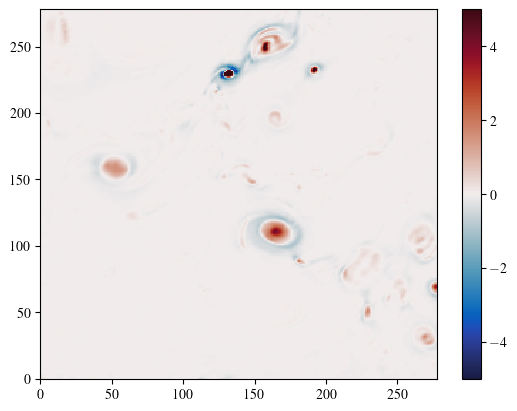

In [95]:
plt.pcolor(irfft2(CYCLO_TERM__(press_lpndim__))[xl:xh,yl:yh]/f/f, cmap=cmo.balance, vmin=-5, vmax=5)
plt.colorbar()

# print(np.std(irfft2(ZETAp1__(press_lpndim__))))

In [168]:
eps = Ro

In [177]:
def err(params):

    params__ = rfft2(params)

    z0 = ZETA_QG__(params__)
    cyclo_corr = CYCLO_TERM__(params__)
    # zp1_corr = ZP1_TERM__(params__)

    err_spec = 1+(Kaa**(2))
    # err_spec = 1
    
    return jnp.sum( jnp.abs(press_lpndim__*(-K2)-z0-eps*(cyclo_corr) )**2*err_spec )

In [187]:
from jaxopt import OptaxSolver

# lr_scheduler = optax.exponential_decay(1e-2, 200, .5)  # decrease the learning rate
# optim = optax.sgd(learning_rate=lr_scheduler)  # basic SGD works nicely
# optim = optax.chain(optax.clip(1), optim)  # prevent updates from exploding

# optim = optax.sgd(learning_rate=0.003)
# solver = jaxopt.OptaxSolver(opt=optim, fun=err, maxiter=300, tol=1e-13)

solver = jaxopt.LBFGS(fun=err, maxiter=10000, tol=1e-13)

In [188]:
res = solver.run(press_lpndim)
# res = solver.run(params__)

In [181]:
params, state = res;
print(state[0])
print(err(press_lpndim))
print(state[1])
print(state[1]/err(press_lpndim))

params__ = rfft2(params)
# params__ = rfft2(press_lpndim)

1000
1.5183921e-09
5.4712657e-10
0.36033288


In [182]:
totp1pres__ = ( params__+eps*CYCLO_TERM__(params__)*-Kn2 )
totp1pres = irfft2( totp1pres__ )

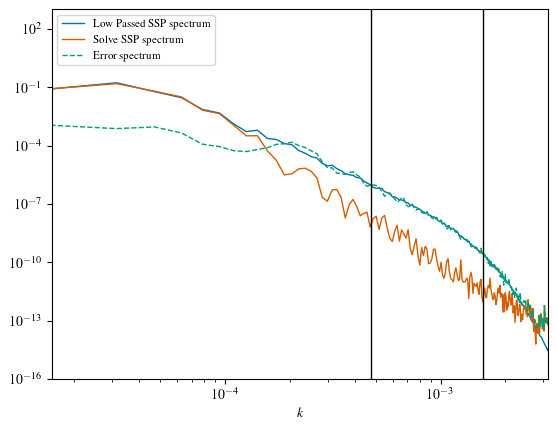

In [183]:
press_spec = isospec_rfft( np.abs(press_lpndim__)**2 )
# params_spec = isospec_rfft( np.abs(params__)**2 )
totp1pres_spec = isospec_rfft( np.abs(totp1pres__)**2 )
err_spec = isospec_rfft( np.abs(press_lpndim__-totp1pres__)**2 )

k_ndim = np.arange(0,press_spec.size,1.)*(kx_Ld[1])
k_fac = kx_Ld[1]/(1/1e3)
plt.loglog(k_ndim,press_spec,label="Low Passed SSP spectrum")
plt.loglog(k_ndim,totp1pres_spec,label="Solve SSP spectrum")
plt.loglog(k_ndim,err_spec,'--',label="Error spectrum")

# plt.loglog(k_ndim,k_ndim**(-const_slope)/const_eta/Ro**2,'k')

# plt.axvline(1/15*k_fac,color='k')
# plt.axvline(1/38*k_fac,color='k')
plt.axvline(1/33*k_fac,color='k')
plt.axvline(1/10*k_fac,color='k')

plt.ylim([1e-16,1e3])
plt.xlabel("$k$ ")
plt.legend()

In [184]:
zeta_SQGp1__ = Ro*(ZETA_QG__(params__))
zeta_SQGp1__ = zeta_SQGp1__*lowpass_filter**0

zeta_Truth__ = rfft2(ds_lpfilter.zeta_windowed.values)*lowpass_filter**0
zeta_Truth = irfft2(zeta_Truth__)

0.8652844
0.44934562
-0.9256544


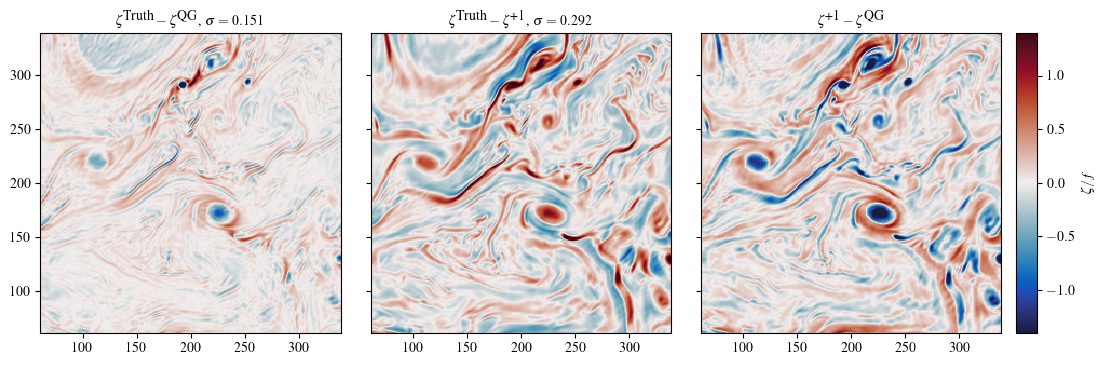

In [185]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values
# xl = 0; xh = -1;
# yl = 0; yh = -1;

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.4

zeta_truth_crop = zeta_Truth[xl:xh,yl:yh]
zeta_GeoBal_crop = ds_GeoBal.zeta_GeoBal.values[xl:xh,yl:yh]
zeta_SQGp1_crop = irfft2(zeta_SQGp1__)[xl:xh,yl:yh] / f

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[0].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{QG}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_GeoBal_crop))
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_SQGp1_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[1].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{+1}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_SQGp1_crop))
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(zeta_SQGp1_crop-zeta_GeoBal_crop), cmap=cmo.balance, vmin=-cmax/1, vmax=cmax/1)
grid[2].set_title(r"$\zeta^\textrm{+1}-\zeta^\textrm{QG}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\zeta/f$")

print(rel_err(zeta_truth_crop,zeta_SQGp1_crop))
print(rel_err(zeta_truth_crop,zeta_GeoBal_crop))
print(1-rel_err(zeta_truth_crop,zeta_SQGp1_crop)/rel_err(zeta_truth_crop,zeta_GeoBal_crop))

In [148]:
# cut_id_2 = 130
# mv_id_x = -20
# mv_id_y = 40

# xl = cut_id_2+mv_id_x; xh = -cut_id_2+mv_id_x
# yl = cut_id_2+mv_id_y; yh = -cut_id_2+mv_id_y

# #############################
# fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

# grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
#                  nrows_ncols=(1,3),
#                  axes_pad=0.3,
#                  share_all=True,
#                  cbar_location="right",
#                  cbar_mode="single",
#                  cbar_size="7%",
#                  cbar_pad=0.15,
#                  )
# cmax = 1.2

# zeta_truth_crop = ds_truth.zeta_surface.values[xl:xh,yl:yh]
# zeta_GeoBal_crop = ds_GeoBal.zeta_GeoBal.values[xl:xh,yl:yh]
# zeta_SQGp1_crop = irfft2(zeta_SQGp1__)[xl:xh,yl:yh]

# im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
# grid[0].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{QG}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_GeoBal_crop))
# im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop-zeta_SQGp1_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
# grid[1].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{+1}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_SQGp1_crop))
# im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(zeta_SQGp1_crop-zeta_GeoBal_crop), cmap=cmo.balance, vmin=-cmax/1, vmax=cmax/1)
# grid[2].set_title(r"$\zeta^\textrm{+1}-\zeta^\textrm{QG}$")

# cbar = grid[2].cax.colorbar(im2)
# cbar.set_label("$\zeta/f$")

# print(rel_err(zeta_truth_crop,zeta_SQGp1_crop))
# print(rel_err(zeta_truth_crop,zeta_GeoBal_crop))
# print(np.std(zeta_truth_crop))

$x$ axis is wavenumber, $y$ axis is the value. Interpretation: 
The curves show how the "intensity" of the vorticity (rotation) is distributed across different spatial sizes.
Since the input is vorticity $\zeta$ normalized by the Coriolis parameter $f$, and the code computes the square magnitude (**2), the Y-value represents the variance of the normalized vorticity (proportional to Enstrophy $\zeta^2$) contained within each wavenumber band.
Higher values: More energy/rotation at that specific scale.
Error Curves (Dashed): Lower dashed lines indicate the model matches the truth well. If an error curve rises to meet the truth curve (the solid lines), the model has lost predictive skill at those smaller scales (typically occurring at high $k$).

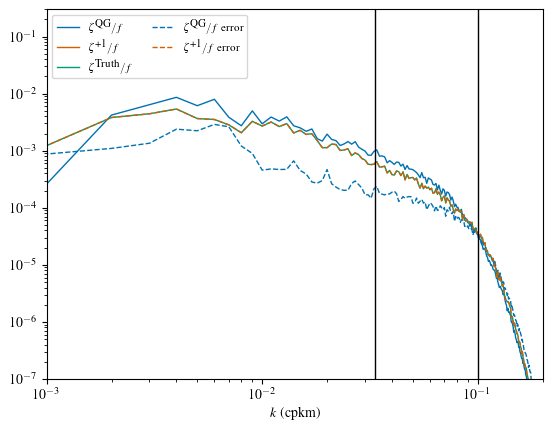

In [149]:
zeta_truth_windowed__ = rfft2(ds_lpfilter.zeta_windowed.values)
zeta_GeoBal__ = rfft2(ds_GeoBal.zeta_GeoBal.values)
zeta_SQGp1 = irfft2(zeta_SQGp1__); zeta_SQGp1__ = rfft2(zeta_SQGp1)

zeta_truth_spec = isospec_rfft( np.abs(zeta_truth_windowed__)**2 )
zeta_GeoBal_spec = isospec_rfft( np.abs(zeta_GeoBal__)**2 )
zeta_SQGp1_spec = isospec_rfft( np.abs(zeta_SQGp1__)**2 )

err_SQGp1_spec = isospec_rfft( np.abs(zeta_SQGp1__-zeta_truth_windowed__)**2 )
err_GeoBal_spec = isospec_rfft( np.abs(zeta_GeoBal__-zeta_truth_windowed__)**2 )

plt.loglog(k_ndim/k_fac,zeta_GeoBal_spec,color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$")
plt.loglog(k_ndim/k_fac,zeta_SQGp1_spec,color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{+1}/f$")
plt.loglog(k_ndim/k_fac,zeta_truth_spec,color=[0.,0.6171875,0.44921875],label=r"$\zeta^\textrm{Truth}/f$")

plt.loglog(k_ndim/k_fac,err_GeoBal_spec,'--',color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$ error")
plt.loglog(k_ndim/k_fac,err_SQGp1_spec,'--',color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{+1}/f$ error")

plt.axvline(1/30,color='k')
plt.axvline(1/10,color='k')
# plt.axvline(1/15,color='k')


plt.ylim([1e-7,0.3])
plt.xlabel("$k$ (cpkm)")
plt.legend(ncol=2)

0.030440378493484986
0.02814648318316977
0.07535699041344601


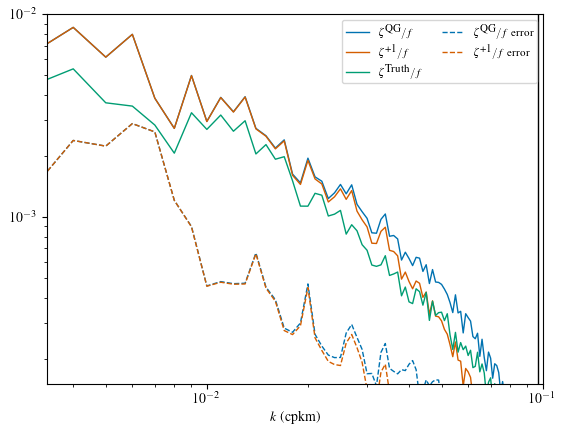

In [139]:
plt.loglog(k_ndim/k_fac,zeta_GeoBal_spec,color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$")
plt.loglog(k_ndim/k_fac,zeta_SQGp1_spec,color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{+1}/f$")
plt.loglog(k_ndim/k_fac,zeta_truth_spec,color=[0.,0.6171875,0.44921875],label=r"$\zeta^\textrm{Truth}/f$")

plt.loglog(k_ndim/k_fac,err_GeoBal_spec,'--',color=[0,0.4453125,0.6953125],label=r"$\zeta^\textrm{QG}/f$ error")
plt.loglog(k_ndim/k_fac,err_SQGp1_spec,'--',color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{+1}/f$ error")

# plt.axvline(1/30,color='k')
# plt.axvline(1/10,color='k')
plt.axvline(k_ndim[97]/k_fac,color='k')

plt.xlim([1/300,1/10])
plt.ylim([1.5e-4,0.01])
plt.xlabel("$k$ (cpkm)")
plt.legend(ncol=2)

print(np.sum(err_GeoBal_spec))
print(np.sum(err_SQGp1_spec))
print(1-np.sum(err_SQGp1_spec)/np.sum(err_GeoBal_spec))

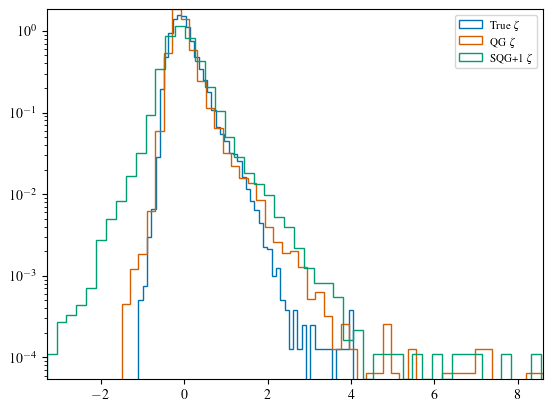

0.03825732283606086
0.09571144342114006


In [71]:
# zrel_lp = irfft2(zeta_rel_lp__)[xl:xh,yl:yh]

plt.hist(zeta_truth_crop.ravel(), log=True, density=True, bins=50, histtype='step',label="True $\zeta$")
plt.hist(zeta_GeoBal_crop.ravel(), log=True, density=True, bins=50, histtype='step',label="QG $\zeta$")
plt.hist(zeta_SQGp1_crop.ravel(), log=True, density=True, bins=50, histtype='step',label="SQG+1 $\zeta$")

plt.legend()
plt.show()

print(wasserstein_distance(zeta_truth_crop.ravel(),zeta_GeoBal_crop.ravel()))
print(wasserstein_distance(zeta_truth_crop.ravel(),zeta_SQGp1_crop.ravel()))

In [65]:
def PHIp1__(phi0s__):
    phi0s_z = irfft2(phi0s__*Ka)
    term_1 = rfft2(1/2*phi0s_z**2)

    phi0s_zz = irfft2(phi0s__*Ka*Ka)
    term_2 = -rfft2(phi0s_z*phi0s_zz)/Kaa

    return term_1+term_2

In [29]:
def FZ_p1__(phi0s__):
    phi0s_y = irfft2((phi0s__.T*1j*ky).T)
    phi0s_zz = irfft2(phi0s__*Ka*Ka)
    phi0s_yz = irfft2((phi0s__.T*1j*ky*Ka.T).T)
    phi0s_z = irfft2(phi0s__*Ka)
    term_1 = rfft2(phi0s_y*phi0s_zz+phi0s_yz*phi0s_z)
    
    term_2 = -(rfft2(phi0s_z*phi0s_y).T*Ka.T).T

    return (term_1+term_2)

In [30]:
def GZ_p1__(phi0s__):
    phi0s_x = irfft2(phi0s__*1j*kx)
    phi0s_zz = irfft2(phi0s__*Ka*Ka)
    phi0s_xz = irfft2(phi0s__*1j*kx*Ka)
    phi0s_z = irfft2(phi0s__*Ka)
    term_1 = -rfft2(phi0s_x*phi0s_zz+phi0s_xz*phi0s_z)
    
    term_2 = +(rfft2(phi0s_z*phi0s_x).T*Ka.T).T

    return (term_1+term_2)

In [31]:
def U_0p1__(phi0s__):
    PHIy_0__ = (phi0s__.T*1j*ky).T
    
    PHIp1__eval = PHIp1__(phi0s__)
    PHIy_p1__ = (PHIp1__eval.T*1j*ky).T
    
    FZ_p1__eval = FZ_p1__(phi0s__)

    return -PHIy_0__+1*eps*(-PHIy_p1__-FZ_p1__eval)

In [32]:
def V_0p1__(phi0s__):
    PHIx_0__ = phi0s__*1j*kx
    
    PHIp1__eval = PHIp1__(phi0s__)
    PHIx_p1__ = PHIp1__eval*1j*kx
    
    GZ_p1__eval = GZ_p1__(phi0s__)

    return PHIx_0__+1*eps*(PHIx_p1__-GZ_p1__eval)

In [33]:
def strain_fuv(phi0s__):
    Ux_p1 = irfft2( U_0p1__(phi0s__)*1j*kx  *lowpass_filter**2)
    Vx_p1 = irfft2( V_0p1__(phi0s__)*1j*kx  *lowpass_filter**2)
    Uy_p1 = irfft2( (U_0p1__(phi0s__).T*1j*ky).T  *lowpass_filter**2)
    Vy_p1 = irfft2( (V_0p1__(phi0s__).T*1j*ky).T  *lowpass_filter**2)
    
    strain_fuvp1 = np.sqrt(  (Ux_p1-Vy_p1)**2+(Vx_p1+Uy_p1)**2  )
    
    strain_fuv__ = rfft2(strain_fuvp1)

    return strain_fuv__

In [34]:
#################
strain_fuv__ = strain_fuv(params__)
# strain_fuv__ = strain_fuv__

# sfuv_p1 = irfft2(strain_fuv__)[xl:xh,yl:yh]

0.694615
0.6616143417079428
0.21467177443830074


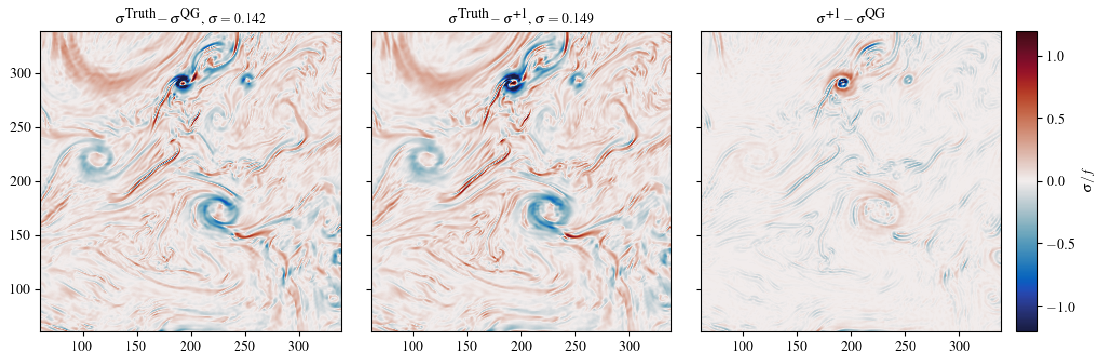

In [35]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.2

strain_truth_crop = ds_truth.strain_surface.values[xl:xh,yl:yh]
strain_GeoBal_crop = ds_GeoBal.strain_GeoBal.values[xl:xh,yl:yh]
strain_SQGp1_crop = irfft2(strain_fuv__)[xl:xh,yl:yh]

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,strain_truth_crop-strain_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[0].set_title(r"$\sigma^\textrm{Truth}-\sigma^\textrm{QG}$, $\sigma=%.3f$" %np.std(strain_truth_crop-strain_GeoBal_crop))
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,strain_truth_crop-strain_SQGp1_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[1].set_title(r"$\sigma^\textrm{Truth}-\sigma^\textrm{+1}$, $\sigma=%.3f$" %np.std(strain_truth_crop-strain_SQGp1_crop))
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(strain_SQGp1_crop-strain_GeoBal_crop), cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[2].set_title(r"$\sigma^\textrm{+1}-\sigma^\textrm{QG}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\sigma/f$")

print(rel_err(strain_truth_crop,strain_SQGp1_crop))
print(rel_err(strain_truth_crop,strain_GeoBal_crop))
print(np.std(strain_truth_crop))


Text(0.5, 1.0, 'Truth')

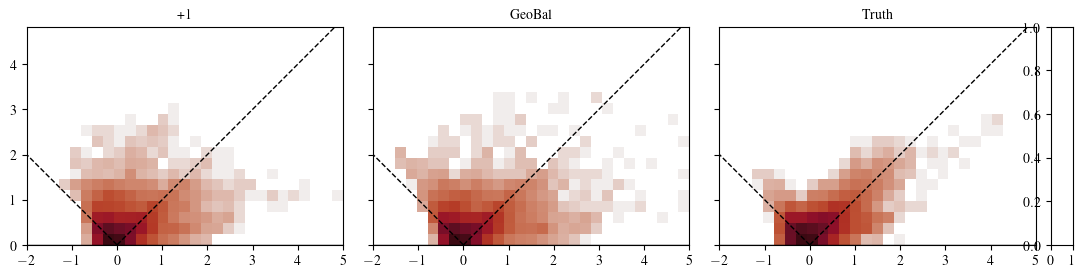

In [36]:
zetat_all = zeta_SQGp1_crop
straint_all = strain_SQGp1_crop

zmax = 5
zmin = -2

z_range = np.linspace(zmin,zmax,30)
s_range = np.arange(0,zmax,z_range[-1]-z_range[-2])
axs_max = zmax

######################################
fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )

im0 = grid[0].hist2d(zetat_all.ravel(),straint_all.ravel(), density=True, bins=[z_range, s_range], cmap=cmo.amp, norm=colors.LogNorm())
grid[0].plot([0,axs_max],[0,axs_max],'--',color='k'); grid[0].plot([0,-axs_max],[0,axs_max],'--',color='k'); grid[0].axhline(0,color='k')
grid[0].set_title("+1")
# plt.axis('equal'); 
# plt.xlim(min(zetat_all.ravel()),max(zetat_all.ravel()))
# plt.ylim(0,max(zetat_all.ravel()))
# plt.colorbar()
# plt.title('Vorticity-Strain JPDF')
# plt.xlabel("Vorticity ($\zeta^t/f$)")
# plt.ylabel("Strain ($\sigma^t/f$)")

######################
zetat_all = zeta_GeoBal_crop
straint_all = strain_GeoBal_crop

im1 = grid[1].hist2d(zetat_all.ravel(),straint_all.ravel(), density=True, bins=[z_range, s_range], cmap=cmo.amp, norm=colors.LogNorm())
grid[1].plot([0,axs_max],[0,axs_max],'--',color='k'); grid[1].plot([0,-axs_max],[0,axs_max],'--',color='k'); grid[1].axhline(0,color='k')
grid[1].set_title("GeoBal")

######################
zetat_all = zeta_truth_crop
straint_all = strain_truth_crop

im2 = grid[2].hist2d(zetat_all.ravel(),straint_all.ravel(), density=True, bins=[z_range, s_range], cmap=cmo.amp, norm=colors.LogNorm())
grid[2].plot([0,axs_max],[0,axs_max],'--',color='k'); grid[2].plot([0,-axs_max],[0,axs_max],'--',color='k'); grid[2].axhline(0,color='k')
grid[2].set_title("Truth")

# grid[2].cax.colorbar()
# cbar.set_label("$\zeta/f$")

# plt.show()